In [1]:
!pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [6]:
df = pd.read_excel('../data/google.xlsx')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/google.xlsx'

In [9]:
df = pd.read_csv('data/google.csv')

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,2.490664,2.591784954,2.390042067,2.499133,2.499133,897427216
1,2004-08-20,2.515820,2.716816902,2.503118038,2.697639,2.697639,458857488
2,2004-08-23,2.758411,2.826406002,2.716069937,2.724787,2.724787,366857939
3,2004-08-24,2.770615,2.77958107,2.579581022,2.611960,2.611960,306396159
4,2004-08-25,2.614201,2.689918041,2.58730197,2.640104,2.640104,184645512


In [10]:
df.shape

(4842, 7)

In [11]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4842 entries, 0 to 4841
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4842 non-null   str    
 1   Open       4842 non-null   float64
 2   High       4842 non-null   str    
 3   Low        4842 non-null   str    
 4   Close      4842 non-null   float64
 5   Adj Close  4842 non-null   float64
 6   Volume     4842 non-null   int64  
dtypes: float64(3), int64(1), str(3)
memory usage: 264.9 KB


In [15]:
df['Date'] = pd.to_datetime(df['Date'])

df['High'] = pd.to_numeric(df['High'], errors='coerce')
df['Low'] = pd.to_numeric(df['Low'], errors='coerce')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4842 entries, 0 to 4841
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4842 non-null   datetime64[us]
 1   Open       4842 non-null   float64       
 2   High       4841 non-null   float64       
 3   Low        4839 non-null   float64       
 4   Close      4842 non-null   float64       
 5   Adj Close  4842 non-null   float64       
 6   Volume     4842 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 264.9 KB


In [17]:
df = df.dropna()

In [18]:
df.shape

(4838, 7)

In [19]:
df = df.sort_values('Date')

In [20]:
df.set_index('Date', inplace=True)

In [21]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-08-19,2.490664,2.591785,2.390042,2.499133,2.499133,897427216
2004-08-20,2.515820,2.716817,2.503118,2.697639,2.697639,458857488
2004-08-23,2.758411,2.826406,2.716070,2.724787,2.724787,366857939
2004-08-24,2.770615,2.779581,2.579581,2.611960,2.611960,306396159
2004-08-25,2.614201,2.689918,2.587302,2.640104,2.640104,184645512


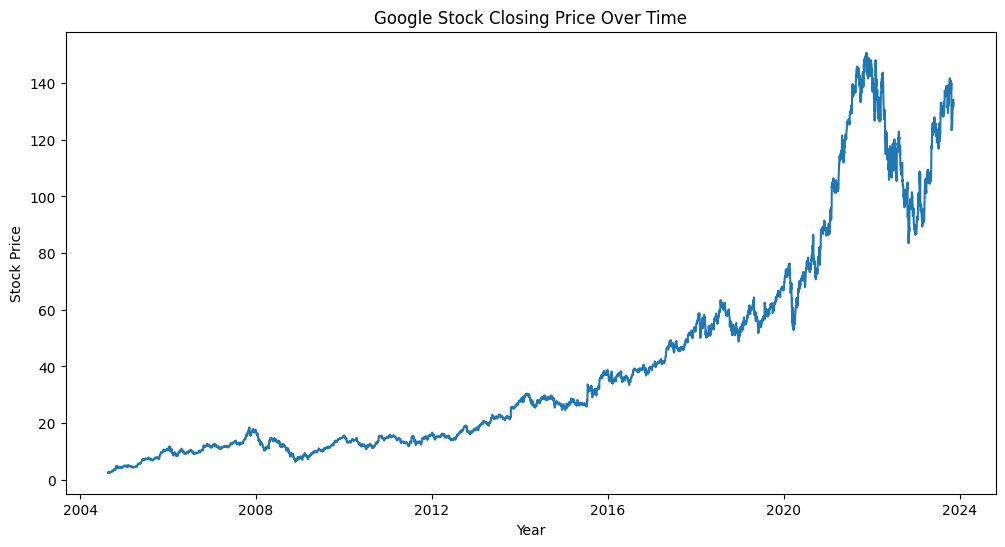

In [30]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'])

plt.title("Google Stock Closing Price Over Time")
plt.xlabel("Year")
plt.ylabel("Stock Price")

plt.savefig('images/price_trend.png')

plt.show()

In [23]:
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

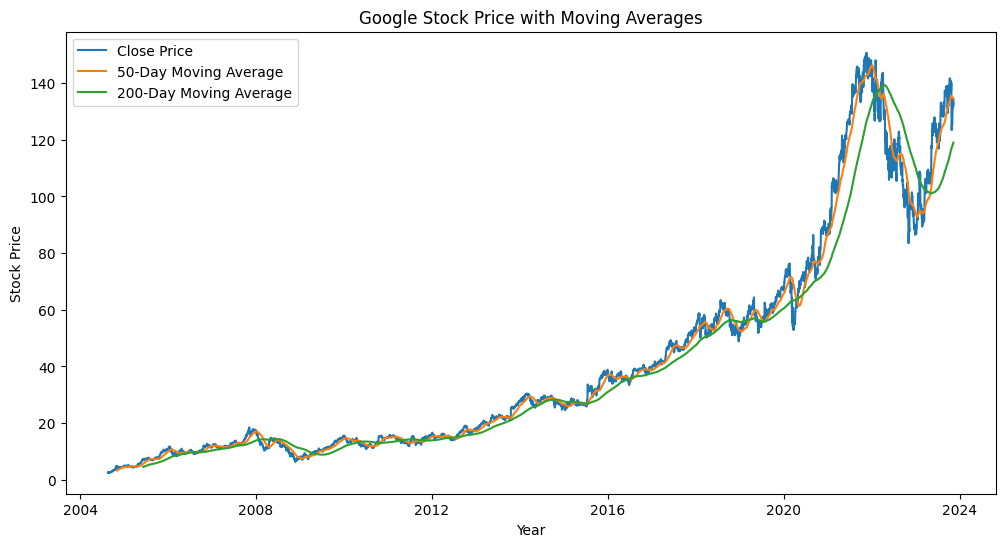

In [31]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA50'], label='50-Day Moving Average')
plt.plot(df['MA200'], label='200-Day Moving Average')

plt.title("Google Stock Price with Moving Averages")
plt.xlabel("Year")
plt.ylabel("Stock Price")

plt.legend()

plt.savefig('images/moving_average.png')

plt.show()

In [25]:
df['Volatility'] = df['High'] - df['Low']

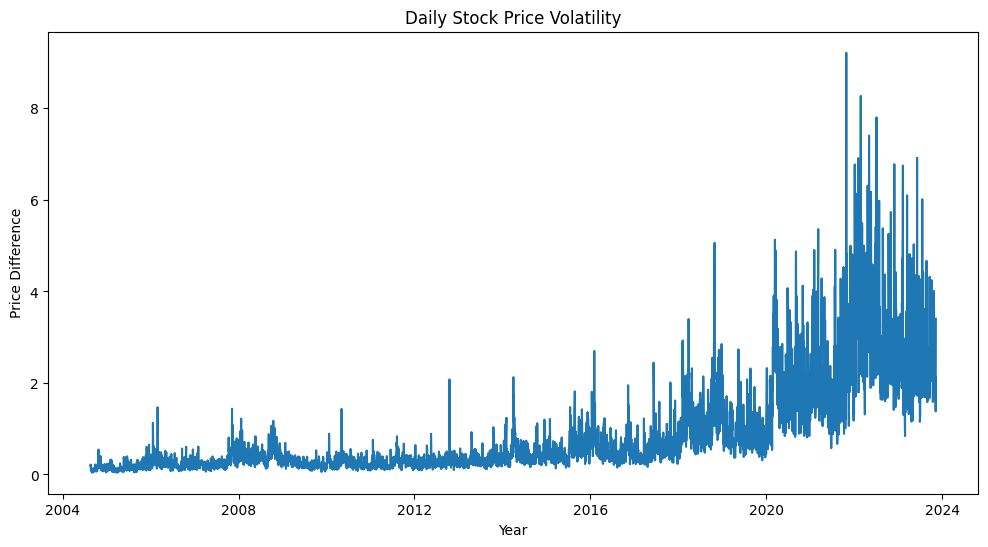

In [26]:
plt.figure(figsize=(12,6))

plt.plot(df['Volatility'])

plt.title("Daily Stock Price Volatility")
plt.xlabel("Year")
plt.ylabel("Price Difference")

plt.show()

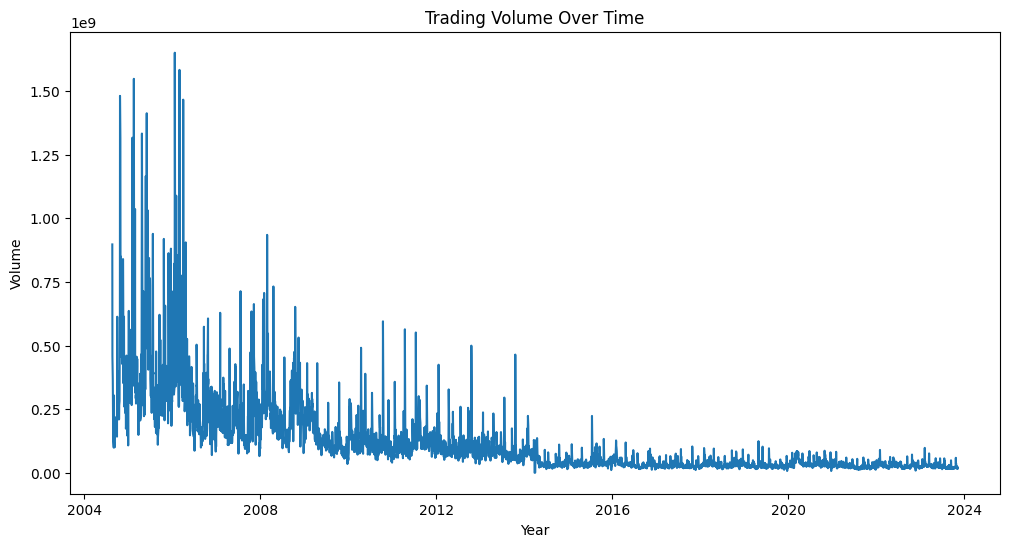

In [27]:
plt.figure(figsize=(12,6))

plt.plot(df['Volume'])

plt.title("Trading Volume Over Time")
plt.xlabel("Year")
plt.ylabel("Volume")

plt.show()

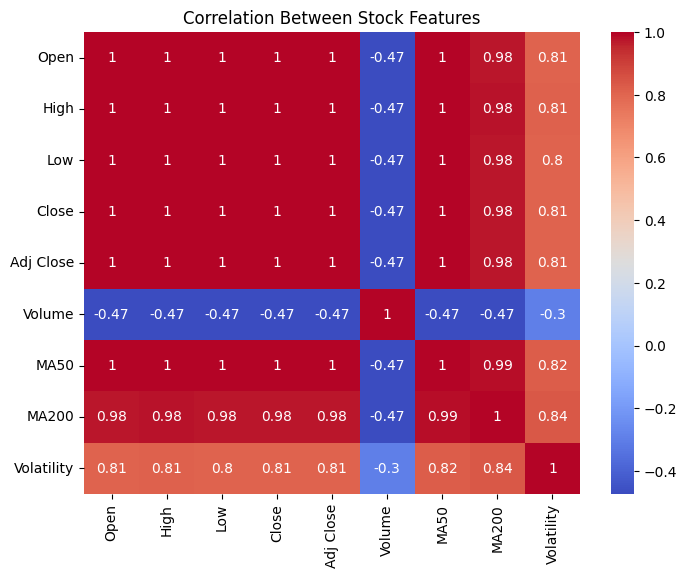

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Between Stock Features")

plt.show()

## Key Insights

1. Google stock shows a strong long-term upward trend from 2004 to 2023.

2. Moving averages (50-day and 200-day) confirm a consistent long-term bullish trend.

3. Volatility increased significantly after 2018, indicating larger daily price swings.

4. Trading volume was highest during the early years after Google went public.

5. Strong correlation exists between Open, High, Low, Close, and Adjusted Close prices.